In [ ]:
 #Montar google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 0.Importación de las librerías

In [ ]:
#Importación de Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #Visualización de Graficas
from sklearn.feature_extraction.text import TfidfVectorizer

# 1.Análisis del Dataset

El dataset fue extraido de Kanggle **[Indian Places to Visit Reviews Data](https://www.kaggle.com/datasets/ritvik1909/indian-places-to-visit-reviews-data/dat)** contiene reseñas de algunos sitios de la India.

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Maestria/ProyectoMineriaOpiniones/Review_db.csv", on_bad_lines='skip')

/tmp/ipykernel_9484/1685329058.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/Maestria/ProyectoMineriaOpiniones/Review_db.csv", on_bad_lines='skip')


In [ ]:
# Ver información del DataSet
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468540 entries, 0 to 1468539
Data columns (total 7 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   City        1468540 non-null  object 
 1   Place       1468536 non-null  object 
 2   Review      1468536 non-null  object 
 3   Rating      1468535 non-null  object 
 4   Name        1468534 non-null  object 
 5   Date        0 non-null        float64
 6   Raw_Review  1468534 non-null  object 
dtypes: float64(1), object(6)
memory usage: 78.4+ MB


In [ ]:
#Ver primeras filas

df.head()

,City,Place,Review,Rating,Name,Date,Raw_Review
0,Aamby Valley City,19 Degree North,aamby valley beautiful place clear blue skies ...,5,Anonymous,NaN,Aamby valley is a beautiful place with its cle...
1,Aamby Valley City,19 Degree North,executed obt akshay thanx team thoroughly enjo...,4,Anonymous,NaN,Very well executed obt by Akshay.... Thanx as ...
2,Aamby Valley City,19 Degree North,awesome experience atv tracts obstacles mainta...,5,Anonymous,NaN,Awesome experience at the ATV\nTracts and obst...
3,Aamby Valley City,19 Degree North,visited aamby valley yesterday short excursion...,4,Anonymous,NaN,we visited the Aamby Valley yesterday for shor...
4,Aamby Valley City,19 Degree North,far mumbai place finest adventure places visit...,5,Anonymous,NaN,"Not far from Mumbai, this place is one of the ..."


In [ ]:
df.head(10)

,City,Place,Review,Raw_Review,Rating,Sentiment,Review_norm,Sentiment_pred
0,Aamby Valley City,19 Degree North,aamby valley beautiful place clear blue skies ...,Aamby valley is a beautiful place with its cle...,5.0,positivo,aamby valley beautiful place clear blue skies ...,positivo
1,Aamby Valley City,19 Degree North,executed obt akshay thanx team thoroughly enjo...,Very well executed obt by Akshay.... Thanx as ...,4.0,positivo,executed obt akshay thanx team thoroughly enjo...,positivo
2,Aamby Valley City,19 Degree North,awesome experience atv tracts obstacles mainta...,Awesome experience at the ATV\nTracts and obst...,5.0,positivo,awesome experience atv tracts obstacles mainta...,positivo
3,Aamby Valley City,19 Degree North,visited aamby valley yesterday short excursion...,we visited the Aamby Valley yesterday for shor...,4.0,positivo,visited aamby valley yesterday short excursion...,positivo
4,Aamby Valley City,19 Degree North,far mumbai place finest adventure places visit...,"Not far from Mumbai, this place is one of the ...",5.0,positivo,far mumbai place finest adventure places visit...,positivo
5,Aamby Valley City,19 Degree North,yearn adrenaline rush place try atv forester m...,if you yearn for the adrenaline rush then this...,5.0,positivo,yearn adrenaline rush place try atv forester m...,positivo
6,Aamby Valley City,19 Degree North,great adventure place recommend x jungle safar...,A great adventure place .I recommend there 4x...,5.0,positivo,great adventure place recommend x jungle safar...,positivo
7,Abhaneri,Chand Baori (Step well),visit jaipur trip usually itinerary need ask t...,This is a must visit on your Jaipur trip. It i...,4.0,positivo,visit jaipur trip usually itinerary need ask t...,positivo
8,Abhaneri,Chand Baori (Step well),happen traveling jaipur agra vice versa detour...,If you happen to be traveling from Jaipur to A...,3.0,neutral,happen traveling jaipur agra vice versa detour...,neutral
9,Abhaneri,Chand Baori (Step well),chand bawari located villege abhaneri near dou...,Chand bawari is located in villege Abhaneri ne...,3.0,neutral,chand bawari located villege abhaneri near dou...,neutral


In [ ]:
# Dimensiones del Dataset
print(f"Dimensiones del dataset: {df.shape}")


Dimensiones del dataset: (1468540, 7)


In [ ]:
#tipos de datos
print("\nTipos de datos:")
print(df.dtypes)


Tipos de datos:
City           object
Place          object
Review         object
Rating         object
Name           object
Date          float64
Raw_Review     object
dtype: object


In [ ]:
#Revisar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

#Revisar duplicados
print("\nNúmero de filas duplicadas completas:")
print(df.duplicated().sum())


Valores nulos por columna:
City                0
Place               4
Review              4
Rating              5
Name                6
Date          1468540
Raw_Review          6
dtype: int64

Número de filas duplicadas completas:
14120


## 1.1 Selección de las variables

In [ ]:
df = df[['City', 'Place', 'Review', 'Raw_Review', 'Rating']].copy()

In [ ]:
#Eliminar filas donde falte información importante
df = df.dropna(subset=['Place', 'Review', 'Rating',"Raw_Review"])

In [ ]:
#Eliminar duplicados
df = df.drop_duplicates()

In [ ]:
print("Dimensiones después de limpieza inicial:")
print(df.shape)

Dimensiones después de limpieza inicial:
(1454414, 5)


In [ ]:
display(df.head())

,City,Place,Review,Raw_Review,Rating
0,Aamby Valley City,19 Degree North,aamby valley beautiful place clear blue skies ...,Aamby valley is a beautiful place with its cle...,5
1,Aamby Valley City,19 Degree North,executed obt akshay thanx team thoroughly enjo...,Very well executed obt by Akshay.... Thanx as ...,4
2,Aamby Valley City,19 Degree North,awesome experience atv tracts obstacles mainta...,Awesome experience at the ATV\nTracts and obst...,5
3,Aamby Valley City,19 Degree North,visited aamby valley yesterday short excursion...,we visited the Aamby Valley yesterday for shor...,4
4,Aamby Valley City,19 Degree North,far mumbai place finest adventure places visit...,"Not far from Mumbai, this place is one of the ...",5


In [ ]:
print("\nValores nulos después de la limpieza:")
print(df.isnull().sum())


Valores nulos después de la limpieza:
City          0
Place         0
Review        0
Raw_Review    0
Rating        0
dtype: int64


# 2.Explorar el Dataset

In [ ]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
print("Frecuencia de ratings:")
print(df['Rating'].value_counts().sort_index())

Frecuencia de ratings:
Rating
1.0      8713
2.0     57105
3.0    204352
4.0    509807
5.0    674437
Name: count, dtype: int64


In [ ]:
# Estadísticos básicos
print("\nResumen estadístico de Rating:")
print(df['Rating'].describe())



Resumen estadístico de Rating:
count    1.454414e+06
mean     4.226714e+00
std      8.739524e-01
min      1.000000e+00
25%      4.000000e+00
50%      4.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: Rating, dtype: float64


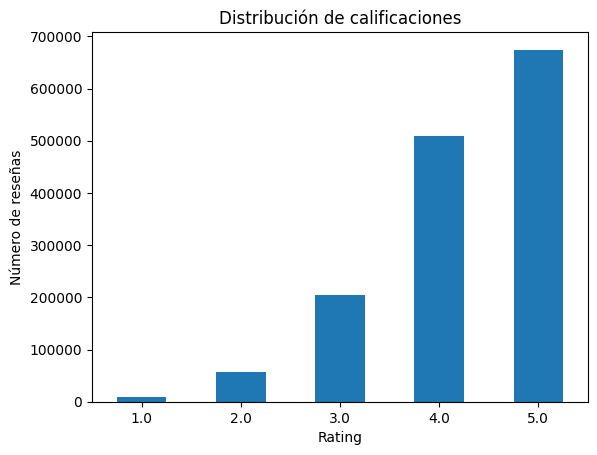

In [ ]:
# Histograma / barras
df['Rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribución de calificaciones")
plt.xlabel("Rating")
plt.ylabel("Número de reseñas")
plt.xticks(rotation=0)
plt.show()

Se llega a observar un gran desbalance entre las clases. Las clases que se dividiran los rating sera: _bueno, neutro y malo_, donde predomina la clase bueno (rating = 4 y 5) dejando en ultima posición malo (rating=1y2=).

In [ ]:
# Número de reseñas por lugar
reviews_por_lugar = df['Place'].value_counts()

print("Número de reseñas por lugar:")
print(reviews_por_lugar.head(20))

Número de reseñas por lugar:
Place
Taj Mahal                      23215
Amber Fort                     13960
Gateway of India               10702
Qutub Minar                    10277
Swaminarayan Akshardham        10163
Bandra-Worli Sea Link           9152
Agra Fort                       8564
India Gate                      8317
Marine Drive                    8176
Wonderla Amusement Park         8133
Humayun's Tomb                  7964
City Palace of Udaipur          7647
Mehrangarh Fort                 6623
Hawa Mahal - Palace of Wind     6554
Baga Beach                      6538
ISKCON Temple Bangalore         6300
Jantar Mantar - Jaipur          5862
Lalbagh Botanical Garden        5803
Gurudwara Bangla Sahib          5573
Mysore Palace (Amba Vilas)      5516
Name: count, dtype: int64


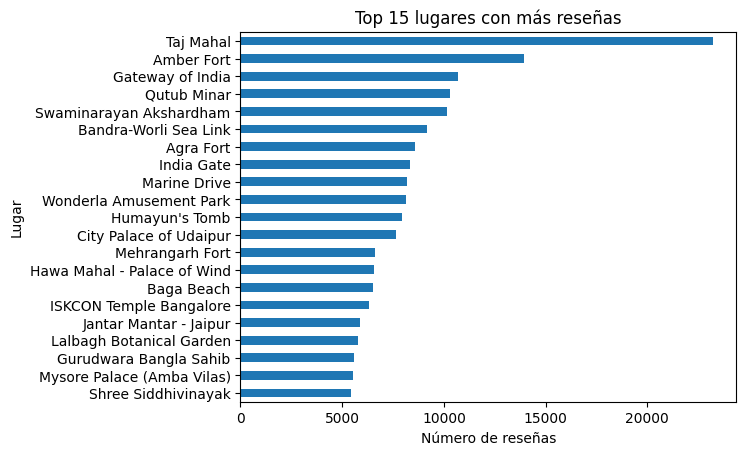

In [ ]:
reviews_por_lugar.head(21).plot(kind='barh')
plt.title("Top 15 lugares con más reseñas")
plt.xlabel("Número de reseñas")
plt.ylabel("Lugar")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
#rating por lugares
rating_por_lugar = df.groupby('Place')['Rating'].agg(['count', 'mean']).reset_index()
rating_por_lugar = rating_por_lugar.sort_values(by='mean', ascending=False)

print("Lugares con mayor promedio de rating:")
display(rating_por_lugar.head(20))

Lugares con mayor promedio de rating:


,Place,count,mean
11558,Side Street Explorers,1,5.0
5891,Kanva Ashram,1,5.0
14346,tour2sundarban,1,5.0
9624,Prospect Point,5,5.0
9621,Priyanka RCM store DAHEJ,5,5.0
1266,Bardhaman Science Centre,3,5.0
12598,Swami Budha Amarnath Ji Mandir,1,5.0
12597,Swami Brahmanand Cave,1,5.0
9606,Pride Resorts,8,5.0
11889,Sri Bhadrakali Temple,1,5.0


In [ ]:
#¿Cuantos lugares solo tienen una reseña?
rating_por_lugar = df.groupby('Place')['Rating'].agg(['count', 'mean']).reset_index()
rating_por_lugar_1_review = rating_por_lugar[rating_por_lugar['count'] == 1]
rating_por_lugar_1_review = rating_por_lugar_1_review.sort_values(by='count', ascending=False)

print("Lugares con solo 1 reseña:")
print("CAntidad de lugares con 1 reseña ",len(rating_por_lugar_1_review))
display(rating_por_lugar_1_review)

Lugares con solo 1 reseña:
CAntidad de lugares con 1 reseña  1112


,Place,count,mean
14347,unseen_uttrakhand,1,4.0
5,108 Parshwanath Bhaktivihar Tirth,1,5.0
7,108 Vinayagar Temple,1,5.0
23,9D VR Cinema Experience,1,4.0
29,AAN Adventure,1,5.0
...,...,...,...
143,Adi Subhrahmanya Temple,1,5.0
121,Adayar Broken Bridge,1,2.0
108,Achirupakkam,1,2.0
92,Achal Sahib,1,4.0


In [ ]:
lugares_filtrados = rating_por_lugar[rating_por_lugar['count'] >= 5].copy()
lugares_filtrados = lugares_filtrados.sort_values(by='mean', ascending=False)

print("Lugares con al menos 5 reseñas:")
display(lugares_filtrados.head(20))

Lugares con al menos 5 reseñas:


,Place,count,mean
4614,Hatnur Dam,7,5.0
14342,movieEX,5,5.0
11181,Shree Ayyappa Vishnu Temple,5,5.0
128,Adhbut Temple,6,5.0
12735,Tana Bana maheshwari handloom,6,5.0
5856,Kanjaripuzha Dam,6,5.0
1374,Belghar Nature Camp,5,5.0
6160,Kerala Private Tours,12,5.0
5104,Jadeshwar Temple,7,5.0
6133,Kelva Beach,12,5.0


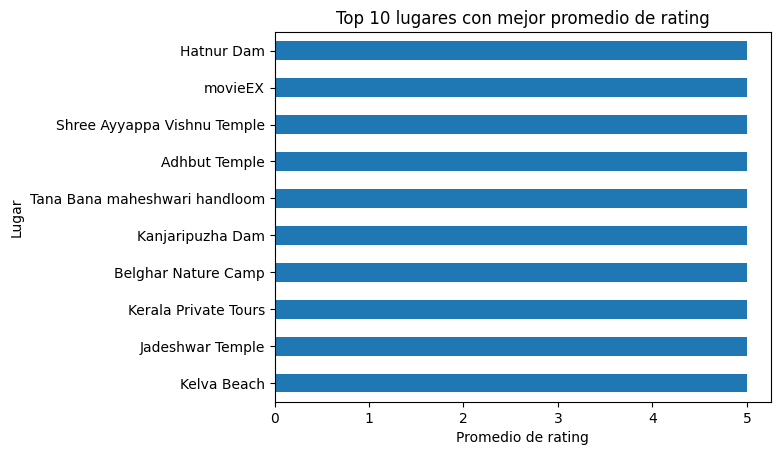

In [ ]:
#Ver los lugares con mejor percepción
top_lugares = lugares_filtrados.head(10)

top_lugares.plot(x='Place', y='mean', kind='barh', legend=False)
plt.title("Top 10 lugares con mejor promedio de rating")
plt.xlabel("Promedio de rating")
plt.ylabel("Lugar")
plt.gca().invert_yaxis()
plt.show()

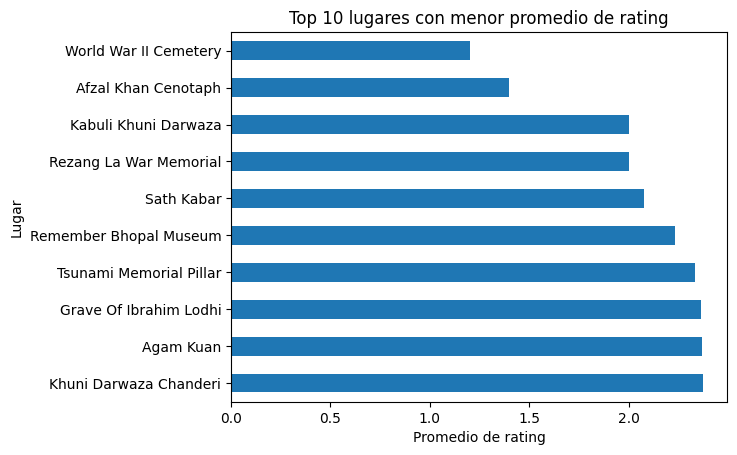

In [ ]:
#Ver los lugares con peor percepción
peores_lugares = lugares_filtrados.sort_values(by='mean', ascending=True).head(10)

peores_lugares.plot(x='Place', y='mean', kind='barh', legend=False)
plt.title("Top 10 lugares con menor promedio de rating")
plt.xlabel("Promedio de rating")
plt.ylabel("Lugar")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
#Analisis por ciudad
rating_por_ciudad = df.groupby('City')['Rating'].agg(['count', 'mean']).reset_index()
rating_por_ciudad = rating_por_ciudad.sort_values(by='mean', ascending=False)

print("Promedio de rating por ciudad:")
display(rating_por_ciudad)

Promedio de rating por ciudad:


,City,count,mean
31,Alirajpur,1,5.000000
847,Kulasekharam,1,5.000000
860,Kuravilangad,3,5.000000
792,Kidanganad,1,5.000000
796,Kodagurki,1,5.000000
...,...,...,...
1093,Nambol,2,2.000000
546,Haddo,1,2.000000
509,Godda,1,2.000000
1245,Phillaur,1,2.000000


## Conclusion del paso
El análisis exploratorio mostró que las calificaciones presentan una distribución desbalanceada, con predominio de valores altos, especialmente 4 y 5 estrellas, lo que sugiere una tendencia general hacia opiniones positivas. Además, se identificaron lugares con una cantidad muy reducida de reseñas, incluyendo 30 sitios con una sola opinión, por lo que será necesario establecer un umbral mínimo de observaciones para realizar comparaciones más confiables entre lugares.

# Crear variables para el sentimiento

In [ ]:
# Crear variable de sentimiento a partir de Rating
def etiquetar_sentimiento(rating):
    if rating in [1, 2]:
        return 'negativo'
    elif rating == 3:
        return 'neutral'
    elif rating in [4, 5]:
        return 'positivo'
    else:
        return None


In [ ]:
df['Sentiment'] = df['Rating'].apply(etiquetar_sentimiento)



In [ ]:
display(df.head(10))

,City,Place,Review,Raw_Review,Rating,Sentiment
0,Aamby Valley City,19 Degree North,aamby valley beautiful place clear blue skies ...,Aamby valley is a beautiful place with its cle...,5.0,positivo
1,Aamby Valley City,19 Degree North,executed obt akshay thanx team thoroughly enjo...,Very well executed obt by Akshay.... Thanx as ...,4.0,positivo
2,Aamby Valley City,19 Degree North,awesome experience atv tracts obstacles mainta...,Awesome experience at the ATV\nTracts and obst...,5.0,positivo
3,Aamby Valley City,19 Degree North,visited aamby valley yesterday short excursion...,we visited the Aamby Valley yesterday for shor...,4.0,positivo
4,Aamby Valley City,19 Degree North,far mumbai place finest adventure places visit...,"Not far from Mumbai, this place is one of the ...",5.0,positivo
5,Aamby Valley City,19 Degree North,yearn adrenaline rush place try atv forester m...,if you yearn for the adrenaline rush then this...,5.0,positivo
6,Aamby Valley City,19 Degree North,great adventure place recommend x jungle safar...,A great adventure place .I recommend there 4x...,5.0,positivo
7,Abhaneri,Chand Baori (Step well),visit jaipur trip usually itinerary need ask t...,This is a must visit on your Jaipur trip. It i...,4.0,positivo
8,Abhaneri,Chand Baori (Step well),happen traveling jaipur agra vice versa detour...,If you happen to be traveling from Jaipur to A...,3.0,neutral
9,Abhaneri,Chand Baori (Step well),chand bawari located villege abhaneri near dou...,Chand bawari is located in villege Abhaneri ne...,3.0,neutral


In [ ]:
# Verificar resultados
print("Frecuencia de clases de sentimiento:")
print(df['Sentiment'].value_counts())

# Porcentaje
print("\nPorcentaje de clases de sentimiento:")
print(df['Sentiment'].value_counts(normalize=True) * 100)

Frecuencia de clases de sentimiento:
Sentiment
positivo    1184244
neutral      204352
negativo      65818
Name: count, dtype: int64

Porcentaje de clases de sentimiento:
Sentiment
positivo    81.424134
neutral     14.050470
negativo     4.525396
Name: proportion, dtype: float64


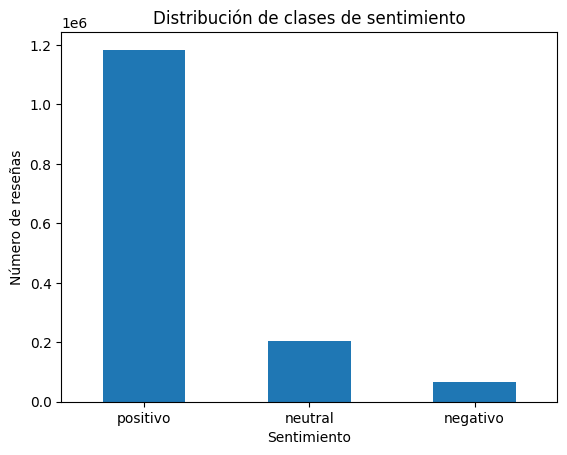

In [ ]:
import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Distribución de clases de sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Número de reseñas")
plt.xticks(rotation=0)
plt.show()

In [ ]:
#valores nulos
print("Valores nulos en Sentiment:")
print(df['Sentiment'].isnull().sum())

Valores nulos en Sentiment:
0


In [ ]:
for clase in ['negativo', 'neutral', 'positivo']:
    print(f"\nReseñas del sentimiento: {clase}")
    ejemplos = df[df['Sentiment'] == clase][['Rating', 'Review', 'Raw_Review']].head(3)
    display(ejemplos)


Reseñas del sentimiento: negativo


,Rating,Review,Raw_Review
13,2.0,astonishing site small village jears old steps...,"Astonishing site in small village , which is ..."
40,2.0,guide advised filled rain water explaining low...,"Our guide advised that this is not a well, but..."
56,2.0,imagining women carrying pots fetch water larg...,Just imagining the women carrying pots to go f...



Reseñas del sentimiento: neutral


,Rating,Review,Raw_Review
8,3.0,happen traveling jaipur agra vice versa detour...,If you happen to be traveling from Jaipur to A...
9,3.0,chand bawari located villege abhaneri near dou...,Chand bawari is located in villege Abhaneri ne...
42,3.0,time saw yrs ago changed past stopped bus smal...,"First time I saw it it was 24 yrs ago, and now..."



Reseñas del sentimiento: positivo


,Rating,Review,Raw_Review
0,5.0,aamby valley beautiful place clear blue skies ...,Aamby valley is a beautiful place with its cle...
1,4.0,executed obt akshay thanx team thoroughly enjo...,Very well executed obt by Akshay.... Thanx as ...
2,5.0,awesome experience atv tracts obstacles mainta...,Awesome experience at the ATV\nTracts and obst...


In [ ]:
import re

def normalizar_repeticiones(texto):
    if pd.isna(texto):
        return texto

    # Si una letra se repite 3 o más veces, la deja solo 2 veces
    texto = re.sub(r'(.)\1{2,}', r'\1\1', texto)

    return texto

df['Review_norm'] = df['Review'].apply(normalizar_repeticiones)

display(df[['Review', 'Review_norm']].head(10))

,Review,Review_norm
0,aamby valley beautiful place clear blue skies ...,aamby valley beautiful place clear blue skies ...
1,executed obt akshay thanx team thoroughly enjo...,executed obt akshay thanx team thoroughly enjo...
2,awesome experience atv tracts obstacles mainta...,awesome experience atv tracts obstacles mainta...
3,visited aamby valley yesterday short excursion...,visited aamby valley yesterday short excursion...
4,far mumbai place finest adventure places visit...,far mumbai place finest adventure places visit...
5,yearn adrenaline rush place try atv forester m...,yearn adrenaline rush place try atv forester m...
6,great adventure place recommend x jungle safar...,great adventure place recommend x jungle safar...
7,visit jaipur trip usually itinerary need ask t...,visit jaipur trip usually itinerary need ask t...
8,happen traveling jaipur agra vice versa detour...,happen traveling jaipur agra vice versa detour...
9,chand bawari located villege abhaneri near dou...,chand bawari located villege abhaneri near dou...


#4.División de los datos

In [ ]:
X = df['Review_norm'] #variable de entrada (reseñas en texto)
y = df['Sentiment'] #variable objetivo (rating)

print("Primeras entradas de X:")
display(X.head())



Primeras entradas de X:


,Review_norm
0,aamby valley beautiful place clear blue skies ...
1,executed obt akshay thanx team thoroughly enjo...
2,awesome experience atv tracts obstacles mainta...
3,visited aamby valley yesterday short excursion...
4,far mumbai place finest adventure places visit...


In [ ]:
print("\nPrimeras entradas de y:")
display(y.head())


Primeras entradas de y:


,Sentiment
0,positivo
1,positivo
2,positivo
3,positivo
4,positivo


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, #variable objetivo
    test_size=0.2, #partición de los datos
    random_state=42, #Semilla
    stratify=y #Conservar la proporsión de las clases
)

In [ ]:
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

Tamaño de X_train: (1163531,)
Tamaño de X_test: (290883,)
Tamaño de y_train: (1163531,)
Tamaño de y_test: (290883,)


In [ ]:
print("Distribución de clases en y_train:")
print(y_train.value_counts())

print("\nDistribución porcentual en y_train:")
print(round(y_train.value_counts(normalize=True) * 100, 2))

print("\nDistribución de clases en y_test:")
print(y_test.value_counts())

print("\nDistribución porcentual en y_test:")
print(round(y_test.value_counts(normalize=True) * 100, 2))

Distribución de clases en y_train:
Sentiment
positivo    947395
neutral     163482
negativo     52654
Name: count, dtype: int64

Distribución porcentual en y_train:
Sentiment
positivo    81.42
neutral     14.05
negativo     4.53
Name: proportion, dtype: float64

Distribución de clases en y_test:
Sentiment
positivo    236849
neutral      40870
negativo     13164
Name: count, dtype: int64

Distribución porcentual en y_test:
Sentiment
positivo    81.42
neutral     14.05
negativo     4.53
Name: proportion, dtype: float64


# 5.Vectorizar texto con TF-IDF

In [ ]:
tfidf = TfidfVectorizer()

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
print("Dimensiones de X_train_tfidf:", X_train_tfidf.shape)
print("Dimensiones de X_test_tfidf:", X_test_tfidf.shape)

Dimensiones de X_train_tfidf: (1163531, 215008)
Dimensiones de X_test_tfidf: (290883, 215008)


In [ ]:
print("Número de términos en el vocabulario:", len(tfidf.vocabulary_))

Número de términos en el vocabulario: 215008


In [ ]:
vocabulario = list(tfidf.vocabulary_.keys())

print("Primeras 20 palabras del vocabulario:")
print(vocabulario[:20])

Primeras 20 palabras del vocabulario:
['sunset', 'sunrise', 'huge', 'clean', 'lake', 'available', 'boating', 'food', 'frankly', 'hardly', 'min', 'stop', 'religious', 'place', 'visit', 'rivers', 'meet', 'water', 'flow', 'interesting']


In [ ]:
# Ver matriz

feature_names = tfidf.get_feature_names_out()

df_tfidf_muestra = pd.DataFrame(
    X_train_tfidf[:5, :10].toarray(),
    columns=feature_names[:10]
)

display(df_tfidf_muestra)

,__,__do,__good,__memorable,__minimam,__very,_a,_all_,_almora,_check
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
palabras_ordenadas = sorted(tfidf.get_feature_names_out())

print("Número de palabras:", len(palabras_ordenadas))
print(palabras_ordenadas[:                         1000])

Número de palabras: 215008
['__', '__do', '__good', '__memorable', '__minimam', '__very', '_a', '_all_', '_almora', '_check', '_contactjamesadrian', '_deer', '_dhoti', '_gowtham_gunturu', '_kumbakonam', '_lacs', '_large', '_leh', '_mela', '_mohan_', '_nabha', '_new_delhi', '_noida', '_not', '_not_', '_nov', '_november', '_person', '_pune', '_roundtrip', '_rs', '_saket_', '_somanathapura', '_start', '_t', '_the', '_the_', '_ticket', '_udaipur', '_vashishti', '_x', '_ysiu', 'aa', 'aab', 'aabhas', 'aabhathsakayewwarar', 'aabhishakam', 'aabian', 'aabideen', 'aabig', 'aabshar', 'aabut', 'aabyr', 'aac', 'aaccordingly', 'aach', 'aacha', 'aachaar', 'aachan', 'aachar', 'aachariyar', 'aacharya', 'aache', 'aachen', 'aachha', 'aachi', 'aachman', 'aactivities', 'aacute', 'aad', 'aadarsh', 'aadat', 'aade', 'aadesh', 'aadeshwar', 'aadh', 'aadha', 'aadhaar', 'aadhar', 'aadheenam', 'aadhenam', 'aadhi', 'aadhikesava', 'aadhinam', 'aadhinathar', 'aadhiseshan', 'aadhishakti', 'aadhmi', 'aadhosesha', 'aadh

In [ ]:
#Palabrqas con mayor importancia
suma_tfidf = X_train_tfidf.sum(axis=0).A1

df_importancia = pd.DataFrame({
    'palabra': tfidf.get_feature_names_out(),
    'peso_total': suma_tfidf
})

df_importancia = df_importancia.sort_values(by='peso_total', ascending=False)

display(df_importancia.head(30))

,palabra,peso_total
143177,place,43890.266489
205662,visit,30901.713346
187637,temple,30418.721770
73195,good,25790.844867
191984,time,18928.332269
20010,beautiful,18668.110769
128517,nice,18341.373524
19674,beach,17836.383616
74431,great,14947.953972
204387,view,14785.413205


In [ ]:
vocabulario = tfidf.get_feature_names_out()

df_vocab = pd.DataFrame({'palabra': vocabulario})

# Busca palabras con una letra repetida 3 o más veces seguidas
palabras_repetidas = df_vocab[
    df_vocab['palabra'].str.contains(r'(.)\1{2,}', regex=True, na=False)
].sort_values('palabra')

print("Cantidad de palabras con repeticiones exageradas:", len(palabras_repetidas))
display(palabras_repetidas.head(50))

Cantidad de palabras con repeticiones exageradas: 0


/tmp/ipykernel_9484/1720550427.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_vocab['palabra'].str.contains(r'(.)\1{2,}', regex=True, na=False)


,palabra


# 6.Modelo usando columna review

## Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Crear modelo
nb_model = MultinomialNB()

# Entrenar
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
print("Con columna Review")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

# Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_nb))

Con columna Review
Accuracy: 0.8154997026295796

Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.90      0.01      0.02     13164
     neutral       0.50      0.01      0.02     40870
    positivo       0.82      1.00      0.90    236849

    accuracy                           0.82    290883
   macro avg       0.74      0.34      0.31    290883
weighted avg       0.78      0.82      0.74    290883



In [ ]:
from sklearn.metrics import confusion_matrix

matriz_nb = confusion_matrix(y_test, y_pred_nb)

df_matriz_nb = pd.DataFrame(
    matriz_nb,
    index=['negativo', 'neutral', 'positivo'],
    columns=['negativo', 'neutral', 'positivo']
)

display(df_matriz_nb)

,negativo,neutral,positivo
negativo,136,233,12795
neutral,12,414,40444
positivo,3,181,236665


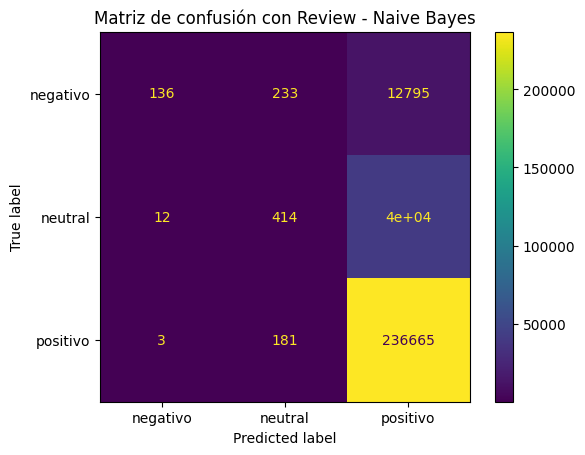

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    nb_model,
    X_test_tfidf,
    y_test,
    display_labels=['negativo', 'neutral', 'positivo']
)
plt.title("Matriz de confusión con Review - Naive Bayes")
plt.show()

El modelo base Multinomial Naive Bayes presentó un sesgo importante hacia la clase positiva, logrando una accuracy relativamente alta debido al desbalance del conjunto de datos, pero con un desempeño deficiente en las clases negativa y neutral. Por ello, este modelo no resulta adecuado como clasificador final para el problema multiclase planteado.

## REgresión logistica

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

print("CON COLUMAN REVIEW")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_lr))

CON COLUMAN REVIEW
Accuracy: 0.9260836831303307

Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.76      0.88      0.82     13164
     neutral       0.69      0.90      0.78     40870
    positivo       1.00      0.93      0.96    236849

    accuracy                           0.93    290883
   macro avg       0.81      0.90      0.85    290883
weighted avg       0.94      0.93      0.93    290883



In [ ]:
matriz_lr = confusion_matrix(y_test, y_pred_lr)

df_matriz_lr = pd.DataFrame(
    matriz_lr,
    index=['negativo', 'neutral', 'positivo'],
    columns=['negativo', 'neutral', 'positivo']
)

display(df_matriz_lr)

,negativo,neutral,positivo
negativo,11599,1490,75
neutral,3128,36797,945
positivo,493,15370,220986


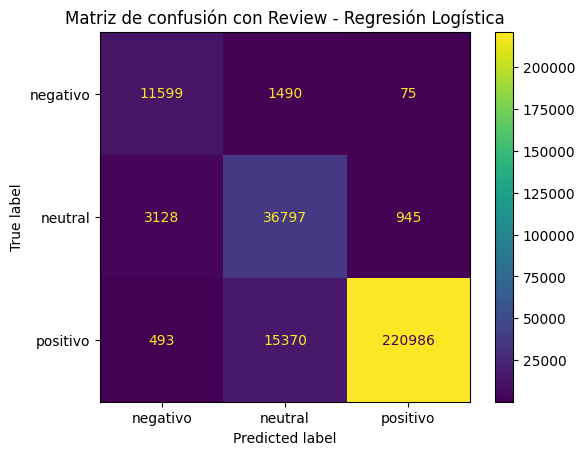

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test_tfidf,
    y_test,
    display_labels=['negativo', 'neutral', 'positivo']
)
plt.title("Matriz de confusión con Review - Regresión Logística")
plt.show()

La regresión logística mostró un desempeño considerablemente superior al modelo base Naive Bayes, especialmente en las clases minoritarias. Aunque persiste cierta confusión entre las clases negativa y neutral, el modelo logró una clasificación más equilibrada en el problema multiclase, por lo que constituye una alternativa más adecuada para el análisis de sentimiento en este conjunto de reseñas.

##SVM

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

# Crear modelo
svm_model = LinearSVC(class_weight='balanced', random_state=42)

In [ ]:
# Entrenar
svm_model.fit(X_train_tfidf, y_train)

# Predecir
y_pred_svm = svm_model.predict(X_test_tfidf)

In [ ]:
# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.9506536992536518

Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.71      0.67      0.69     13164
     neutral       0.81      0.86      0.84     40870
    positivo       0.99      0.98      0.99    236849

    accuracy                           0.95    290883
   macro avg       0.84      0.84      0.84    290883
weighted avg       0.95      0.95      0.95    290883




Matriz de confusión:


,negativo,neutral,positivo
negativo,8842,4194,128
neutral,3165,35300,2405
positivo,452,4010,232387


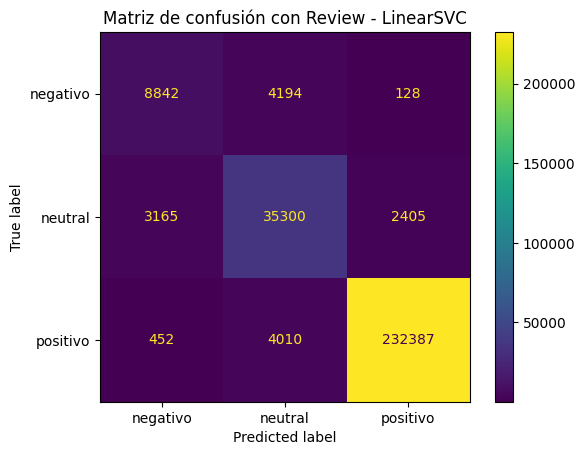

In [ ]:
# Matriz de confusión
matriz_svm = confusion_matrix(y_test, y_pred_svm)

df_matriz_svm = pd.DataFrame(
    matriz_svm,
    index=['negativo', 'neutral', 'positivo'],
    columns=['negativo', 'neutral', 'positivo']
)

print("\nMatriz de confusión:")
display(df_matriz_svm)

# Visualización
ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_test_tfidf,
    y_test,
    display_labels=['negativo', 'neutral', 'positivo']
)
plt.title("Matriz de confusión con Review - LinearSVC")
plt.show()

Al comparar los modelos evaluados, LinearSVC presentó el mejor desempeño global en la clasificación multiclase de las reseñas, superando tanto a Naive Bayes como a la Regresión Logística en accuracy y en F1 promedio. No obstante, la clase negativa continuó siendo la más difícil de identificar, observándose una confusión frecuente con la clase neutral, probablemente debido al desbalance de clases y a la similitud semántica entre opiniones intermedias y desfavorables.

## Comparación de los modelos

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd

resultados = pd.DataFrame({
    'Modelo': ['Naive Bayes', 'Regresión Logística', 'LinearSVC'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm)
    ],
    'Precision_macro': [
        precision_score(y_test, y_pred_nb, average='macro'),
        precision_score(y_test, y_pred_lr, average='macro'),
        precision_score(y_test, y_pred_svm, average='macro')
    ],
    'Recall_macro': [
        recall_score(y_test, y_pred_nb, average='macro'),
        recall_score(y_test, y_pred_lr, average='macro'),
        recall_score(y_test, y_pred_svm, average='macro')
    ],
    'F1_macro': [
        f1_score(y_test, y_pred_nb, average='macro'),
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_svm, average='macro')
    ],
    'F1_weighted': [
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted')
    ]
})

display(resultados.sort_values(by='F1_macro', ascending=False))

,Modelo,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted
1,Regresión Logística,0.926084,0.814426,0.904828,0.853016,0.930658
2,LinearSVC,0.950654,0.836775,0.838852,0.837362,0.950968
0,Naive Bayes,0.815500,0.739006,0.339895,0.312955,0.735376


# 7.Modelos usando la columna Raw_Review

## SVM

In [ ]:
X_raw = df['Raw_Review']
y_raw = df['Sentiment']

In [ ]:
print("Valores nulos en Raw_Review:", X_raw.isnull().sum())

Valores nulos en Raw_Review: 0


In [ ]:
df_raw = df.dropna(subset=['Raw_Review', 'Sentiment']).copy()

X_raw = df_raw['Raw_Review']
y_raw = df_raw['Sentiment']

In [ ]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

In [ ]:
tfidf_raw = TfidfVectorizer(
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

X_train_raw_tfidf = tfidf_raw.fit_transform(X_train_raw)
X_test_raw_tfidf = tfidf_raw.transform(X_test_raw)

print("Dimensiones train:", X_train_raw_tfidf.shape)
print("Dimensiones test:", X_test_raw_tfidf.shape)
print("Tamaño del vocabulario:", len(tfidf_raw.get_feature_names_out()))

Dimensiones train: (1163531, 1453054)
Dimensiones test: (290883, 1453054)
Tamaño del vocabulario: 1453054


In [ ]:
svm_raw_model = LinearSVC(class_weight='balanced', random_state=42)
svm_raw_model.fit(X_train_raw_tfidf, y_train_raw)

LinearSVC(class_weight='balanced', random_state=42)

In [ ]:
y_pred_svm_raw = svm_raw_model.predict(X_test_raw_tfidf)

In [ ]:

print("Con la columna Raw_review")
print("Accuracy:", accuracy_score(y_test_raw, y_pred_svm_raw))

print("\nReporte de clasificación:")
print(classification_report(y_test_raw, y_pred_svm_raw))

Con la columna Raw_review
Accuracy: 0.9320792208551204

Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.65      0.56      0.60     13164
     neutral       0.76      0.79      0.77     40870
    positivo       0.98      0.98      0.98    236849

    accuracy                           0.93    290883
   macro avg       0.80      0.77      0.78    290883
weighted avg       0.93      0.93      0.93    290883



In [ ]:
matriz_svm_raw = confusion_matrix(y_test_raw, y_pred_svm_raw)

df_matriz_svm_raw = pd.DataFrame(
    matriz_svm_raw,
    index=['negativo', 'neutral', 'positivo'],
    columns=['negativo', 'neutral', 'positivo']
)

display(df_matriz_svm_raw)

,negativo,neutral,positivo
negativo,7382,5521,261
neutral,3503,32096,5271
positivo,386,4815,231648


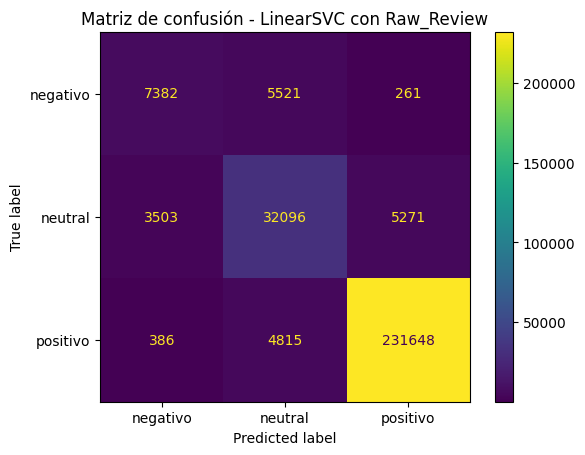

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    svm_raw_model,
    X_test_raw_tfidf,
    y_test_raw,
    display_labels=['negativo', 'neutral', 'positivo']
)
plt.title("Matriz de confusión - LinearSVC con Raw_Review")
plt.show()

## Regresion logistica

In [ ]:
lr_raw_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

In [ ]:
lr_raw_model.fit(X_train_raw_tfidf, y_train_raw)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
y_pred_lr_raw = lr_raw_model.predict(X_test_raw_tfidf)

In [ ]:
print("Regresión logistica\nREsultados con Raw_Review")
print("\nAccuracy:", accuracy_score(y_test_raw, y_pred_lr_raw))

print("\nReporte de clasificación:")
print(classification_report(y_test_raw, y_pred_lr_raw))

Regresión logistica
REsultados con Raw_Review

Accuracy: 0.8993547233767528

Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.64      0.76      0.70     13164
     neutral       0.62      0.84      0.71     40870
    positivo       0.99      0.92      0.95    236849

    accuracy                           0.90    290883
   macro avg       0.75      0.84      0.79    290883
weighted avg       0.92      0.90      0.91    290883



In [ ]:
matriz_lr_raw = confusion_matrix(y_test_raw, y_pred_lr_raw)

df_matriz_lr_raw = pd.DataFrame(
    matriz_lr_raw,
    index=['negativo', 'neutral', 'positivo'],
    columns=['negativo', 'neutral', 'positivo']
)

print("\nMatriz de confusión:")
display(df_matriz_lr_raw)


Matriz de confusión:


,negativo,neutral,positivo
negativo,10006,2990,168
neutral,4305,34376,2189
positivo,1243,18381,217225


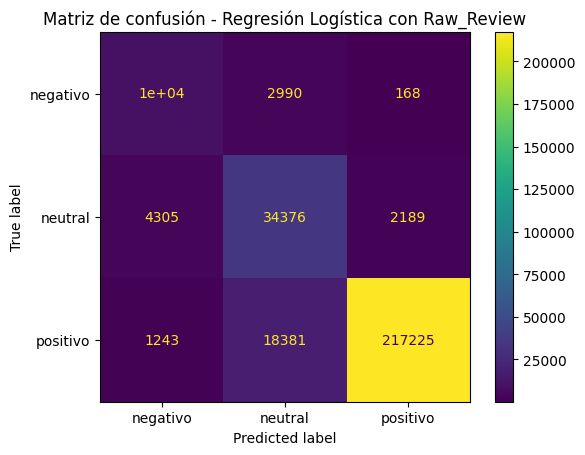

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    lr_raw_model,
    X_test_raw_tfidf,
    y_test_raw,
    display_labels=['negativo', 'neutral', 'positivo']
)
plt.title("Matriz de confusión - Regresión Logística con Raw_Review")
plt.show()

# 8.Calcular percepción del lugar usando ya el modelo

## Entrenar el modelo final con todo el dataset

In [ ]:
# Variables finales
X_final = df['Review']
y_final = df['Sentiment']

In [ ]:
# Vectorizador final
tfidf_final = TfidfVectorizer()

X_final_tfidf = tfidf_final.fit_transform(X_final)

In [ ]:
# Modelo final
modelo_final = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

modelo_final.fit(X_final_tfidf, y_final)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
df['Sentiment_pred'] = modelo_final.predict(X_final_tfidf)

display(df[['Place', 'Review', 'Rating', 'Sentiment', 'Sentiment_pred']].head())

,Place,Review,Rating,Sentiment,Sentiment_pred
0,19 Degree North,aamby valley beautiful place clear blue skies ...,5.0,positivo,positivo
1,19 Degree North,executed obt akshay thanx team thoroughly enjo...,4.0,positivo,positivo
2,19 Degree North,awesome experience atv tracts obstacles mainta...,5.0,positivo,positivo
3,19 Degree North,visited aamby valley yesterday short excursion...,4.0,positivo,positivo
4,19 Degree North,far mumbai place finest adventure places visit...,5.0,positivo,positivo


In [ ]:
df[['Place', 'Review', 'Rating', 'Sentiment', 'Sentiment_pred']].head(10)

,Place,Review,Rating,Sentiment,Sentiment_pred
0,19 Degree North,aamby valley beautiful place clear blue skies ...,5.0,positivo,positivo
1,19 Degree North,executed obt akshay thanx team thoroughly enjo...,4.0,positivo,positivo
2,19 Degree North,awesome experience atv tracts obstacles mainta...,5.0,positivo,positivo
3,19 Degree North,visited aamby valley yesterday short excursion...,4.0,positivo,positivo
4,19 Degree North,far mumbai place finest adventure places visit...,5.0,positivo,positivo
5,19 Degree North,yearn adrenaline rush place try atv forester m...,5.0,positivo,positivo
6,19 Degree North,great adventure place recommend x jungle safar...,5.0,positivo,positivo
7,Chand Baori (Step well),visit jaipur trip usually itinerary need ask t...,4.0,positivo,positivo
8,Chand Baori (Step well),happen traveling jaipur agra vice versa detour...,3.0,neutral,neutral
9,Chand Baori (Step well),chand bawari located villege abhaneri near dou...,3.0,neutral,neutral


## Calcular proporción de sentimientos por lugar

In [ ]:
# Conteo de sentimientos predichos por lugar
tabla_sentimientos = pd.crosstab(df['Place'], df['Sentiment_pred'])

# Convertir a proporciones
proporciones_sentimientos = tabla_sentimientos.div(tabla_sentimientos.sum(axis=1), axis=0)

display(proporciones_sentimientos.head())

Sentiment_pred,negativo,neutral,positivo
Place,,,
1 MG Lido Mall,0.018692,0.233645,0.747664
10 Acres Mall,0.400000,0.200000,0.400000
1008 Lingam Temple,0.011111,0.211111,0.777778
101 Ft. Hanuman Idol,0.000000,0.250000,0.750000
108 Feet Height Statue Of Basaveshwara,0.100000,0.300000,0.600000


## Agregar número de reseñas y rating promedio

In [ ]:
resumen_lugares = df.groupby('Place').agg(
    total_reviews=('Place', 'count'),
    rating_promedio=('Rating', 'mean')
).reset_index()

display(resumen_lugares.head())

,Place,total_reviews,rating_promedio
0,1 MG Lido Mall,107,4.261682
1,10 Acres Mall,5,3.200000
2,1008 Lingam Temple,90,4.300000
3,101 Ft. Hanuman Idol,4,4.500000
4,108 Feet Height Statue Of Basaveshwara,10,4.000000


## Unir todo en una sola tabla

In [ ]:
# Resetear índice para unir
proporciones_sentimientos = proporciones_sentimientos.reset_index()
# Unir con resumen de lugares
percepcion_lugares = resumen_lugares.merge(proporciones_sentimientos, on='Place', how='left')

display(percepcion_lugares.head())

,Place,total_reviews,rating_promedio,negativo,neutral,positivo
0,1 MG Lido Mall,107,4.261682,0.018692,0.233645,0.747664
1,10 Acres Mall,5,3.200000,0.400000,0.200000,0.400000
2,1008 Lingam Temple,90,4.300000,0.011111,0.211111,0.777778
3,101 Ft. Hanuman Idol,4,4.500000,0.000000,0.250000,0.750000
4,108 Feet Height Statue Of Basaveshwara,10,4.000000,0.100000,0.300000,0.600000


In [ ]:
percepcion_lugares = percepcion_lugares.rename(columns={
    'negativo': 'prop_negativo',
    'neutral': 'prop_neutral',
    'positivo': 'prop_positivo'
})

display(percepcion_lugares.head())

,Place,total_reviews,rating_promedio,prop_negativo,prop_neutral,prop_positivo
0,1 MG Lido Mall,107,4.261682,0.018692,0.233645,0.747664
1,10 Acres Mall,5,3.200000,0.400000,0.200000,0.400000
2,1008 Lingam Temple,90,4.300000,0.011111,0.211111,0.777778
3,101 Ft. Hanuman Idol,4,4.500000,0.000000,0.250000,0.750000
4,108 Feet Height Statue Of Basaveshwara,10,4.000000,0.100000,0.300000,0.600000


In [ ]:
# Crear un índice de percepción
percepcion_lugares['indice_percepcion']=(
    percepcion_lugares['prop_positivo'] - percepcion_lugares['prop_negativo']
)

In [ ]:
#Filtrar Lugares con reseñas mayor a 5
percepcion_filtrada = percepcion_lugares[percepcion_lugares['total_reviews'] >= 5].copy()

In [ ]:
#Lugares ordenados con mejor percepción
top_lugares = percepcion_filtrada.sort_values(
    by=['indice_percepcion', 'rating_promedio'],
    ascending=False
)

display(top_lugares.head(20))

,Place,total_reviews,rating_promedio,prop_negativo,prop_neutral,prop_positivo,indice_percepcion
28,AADRIK HOLIDAYS,5,5.0,0.0,0.0,1.0,1.0
37,AUGUSTIN Studio & Gallery,5,5.0,0.0,0.0,1.0,1.0
128,Adhbut Temple,6,5.0,0.0,0.0,1.0,1.0
707,Art Mall,6,5.0,0.0,0.0,1.0,1.0
785,Arya Ayurvedic Centre,8,5.0,0.0,0.0,1.0,1.0
1374,Belghar Nature Camp,5,5.0,0.0,0.0,1.0,1.0
2201,Chandrampalli Dam,6,5.0,0.0,0.0,1.0,1.0
2411,Chinmaya Mission,14,5.0,0.0,0.0,1.0,1.0
2879,Dechen Choekhor Mahavihara Monastery,12,5.0,0.0,0.0,1.0,1.0
2917,Deobandh Temple,7,5.0,0.0,0.0,1.0,1.0


In [ ]:
#Ver lugares con peor percepción
peores_lugares = percepcion_filtrada.sort_values(
    by=['indice_percepcion', 'rating_promedio'],
    ascending=True
)

display(peores_lugares.head(20))

,Place,total_reviews,rating_promedio,prop_negativo,prop_neutral,prop_positivo,indice_percepcion
14201,World War II Cemetery,5,1.200000,1.000000,0.000000,0.000000,-1.000000
178,Afzal Khan Cenotaph,10,1.400000,0.900000,0.100000,0.000000,-0.900000
5546,Kabuli Khuni Darwaza,6,2.000000,0.666667,0.333333,0.000000,-0.666667
10243,Rezang La War Memorial,6,2.000000,0.666667,0.333333,0.000000,-0.666667
13442,Tsunami Memorial Pillar,6,2.333333,0.666667,0.333333,0.000000,-0.666667
10748,Sath Kabar,13,2.076923,0.769231,0.076923,0.153846,-0.615385
1352,Begum Palace Ruins,5,2.400000,0.600000,0.400000,0.000000,-0.600000
10219,Remember Bhopal Museum,13,2.230769,0.692308,0.153846,0.153846,-0.538462
2963,Devarc Mall,8,2.750000,0.625000,0.250000,0.125000,-0.500000
8828,Old English Cemetery,11,3.000000,0.636364,0.181818,0.181818,-0.454545


In [ ]:
peores_lugares = percepcion_filtrada.sort_values(
    by=['indice_percepcion', 'rating_promedio'],
    ascending=True
)

display(peores_lugares.head(20))

,Place,total_reviews,rating_promedio,prop_negativo,prop_neutral,prop_positivo,indice_percepcion
14201,World War II Cemetery,5,1.200000,1.000000,0.000000,0.000000,-1.000000
178,Afzal Khan Cenotaph,10,1.400000,0.900000,0.100000,0.000000,-0.900000
5546,Kabuli Khuni Darwaza,6,2.000000,0.666667,0.333333,0.000000,-0.666667
10243,Rezang La War Memorial,6,2.000000,0.666667,0.333333,0.000000,-0.666667
13442,Tsunami Memorial Pillar,6,2.333333,0.666667,0.333333,0.000000,-0.666667
10748,Sath Kabar,13,2.076923,0.769231,0.076923,0.153846,-0.615385
1352,Begum Palace Ruins,5,2.400000,0.600000,0.400000,0.000000,-0.600000
10219,Remember Bhopal Museum,13,2.230769,0.692308,0.153846,0.153846,-0.538462
2963,Devarc Mall,8,2.750000,0.625000,0.250000,0.125000,-0.500000
8828,Old English Cemetery,11,3.000000,0.636364,0.181818,0.181818,-0.454545


# 9.Descargar los modelos

In [ ]:
import joblib

In [ ]:
joblib.dump(tfidf_final, "vectorizador_tfidf.pkl")
joblib.dump(modelo_final, "modelo_sentimiento.pkl")

['modelo_sentimiento.pkl']

In [ ]:
import os
print(os.listdir())

['.config', 'modelo_sentimiento.pkl', 'vectorizador_tfidf.pkl', 'drive', 'sample_data']


# 10.Pruebas del modelo

In [ ]:
#Cargar modelos
vectorizador_cargado = joblib.load("vectorizador_tfidf.pkl")
modelo_cargado = joblib.load("modelo_sentimiento.pkl")

# 7. Probar con texto nuevo
nuevo_texto = ["happen traveling jaipur agra vice versa detour little"]
texto_vectorizado = vectorizador_cargado.transform(nuevo_texto)
prediccion = modelo_cargado.predict(texto_vectorizado)

print("Predicción:", prediccion[0])

Predicción: neutral


# 11.

In [ ]:
# 1. Conteo de sentimientos predichos por lugar
tabla_lugar_sent = pd.crosstab(df['Place'], df['Sentiment_pred']).reset_index()

# 2. Obtener ciudad, total de reseñas y rating promedio por lugar
resumen_lugar = df.groupby('Place').agg(
    City=('City', 'first'),
    total_reviews=('Place', 'count'),
    rating_promedio=('Rating', 'mean')
).reset_index()

# 3. Unir ambas tablas
tabla_lugares = resumen_lugar.merge(tabla_lugar_sent, on='Place', how='left')

# 4. Si alguna clase no aparece en algún lugar, crearla con 0
for col in ['negativo', 'neutral', 'positivo']:
    if col not in tabla_lugares.columns:
        tabla_lugares[col] = 0


In [ ]:
# 5. Calcular proporciones
tabla_lugares['prop_negativo'] = tabla_lugares['negativo'] / tabla_lugares['total_reviews']
tabla_lugares['prop_neutral'] = tabla_lugares['neutral'] / tabla_lugares['total_reviews']
tabla_lugares['prop_positivo'] = tabla_lugares['positivo'] / tabla_lugares['total_reviews']

# 6. Índice de percepción
tabla_lugares['indice_percepcion'] = (
    tabla_lugares['prop_positivo'] - tabla_lugares['prop_negativo']
)

# 7. Ordenar por mejor percepción
tabla_lugares = tabla_lugares.sort_values(
    by=['indice_percepcion', 'rating_promedio'],
    ascending=False
)

display(tabla_lugares.head(20))

,Place,City,total_reviews,rating_promedio,negativo,neutral,positivo,prop_negativo,prop_neutral,prop_positivo,indice_percepcion
5,108 Parshwanath Bhaktivihar Tirth,Shankheshwar,1,5.0,0,0,1,0.0,0.0,1.0,1.0
7,108 Vinayagar Temple,Dindigul,1,5.0,0,0,1,0.0,0.0,1.0,1.0
15,500 Years Old Shiva Temple,Hooghly,2,5.0,0,0,2,0.0,0.0,1.0,1.0
28,AADRIK HOLIDAYS,Malbazar,5,5.0,0,0,5,0.0,0.0,1.0,1.0
29,AAN Adventure,Baijnath,1,5.0,0,0,1,0.0,0.0,1.0,1.0
30,AAR Mango Farm,Ratnagiri,1,5.0,0,0,1,0.0,0.0,1.0,1.0
37,AUGUSTIN Studio & Gallery,Agonda,5,5.0,0,0,5,0.0,0.0,1.0,1.0
78,Abhishek Pushkarn,Vaishali,1,5.0,0,0,1,0.0,0.0,1.0,1.0
84,Abstract Art Gallery,Bengaluru,3,5.0,0,0,3,0.0,0.0,1.0,1.0
128,Adhbut Temple,Haridwar,6,5.0,0,0,6,0.0,0.0,1.0,1.0


In [ ]:
# 1. Conteo de sentimientos predichos por ciudad
tabla_ciudad_sent = pd.crosstab(df['City'], df['Sentiment_pred']).reset_index()

# 2. Obtener total de reseñas, total de lugares y rating promedio por ciudad
resumen_ciudad = df.groupby('City').agg(
    total_reviews=('City', 'count'),
    total_places=('Place', 'nunique'),
    rating_promedio=('Rating', 'mean')
).reset_index()

# 3. Unir ambas tablas
tabla_ciudades = resumen_ciudad.merge(tabla_ciudad_sent, on='City', how='left')

# 4. Si alguna clase no aparece en alguna ciudad, crearla con 0
for col in ['negativo', 'neutral', 'positivo']:
    if col not in tabla_ciudades.columns:
        tabla_ciudades[col] = 0

# 5. Calcular proporciones
tabla_ciudades['prop_negativo'] = tabla_ciudades['negativo'] / tabla_ciudades['total_reviews']
tabla_ciudades['prop_neutral'] = tabla_ciudades['neutral'] / tabla_ciudades['total_reviews']
tabla_ciudades['prop_positivo'] = tabla_ciudades['positivo'] / tabla_ciudades['total_reviews']

# 6. Índice de percepción
tabla_ciudades['indice_percepcion'] = (
    tabla_ciudades['prop_positivo'] - tabla_ciudades['prop_negativo']
)

# 7. Ordenar por mejor percepción
tabla_ciudades = tabla_ciudades.sort_values(
    by=['indice_percepcion', 'rating_promedio'],
    ascending=False
)

display(tabla_ciudades)

,City,total_reviews,total_places,rating_promedio,negativo,neutral,positivo,prop_negativo,prop_neutral,prop_positivo,indice_percepcion
31,Alirajpur,1,1,5.0,0,0,1,0.0,0.0,1.0,1.0
98,Ausa,3,1,5.0,0,0,3,0.0,0.0,1.0,1.0
99,Avakali,1,1,5.0,0,0,1,0.0,0.0,1.0,1.0
104,Azamgarh,2,1,5.0,0,0,2,0.0,0.0,1.0,1.0
129,Balicha,1,1,5.0,0,0,1,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
793,Kiriburu,1,1,2.0,1,0,0,1.0,0.0,0.0,-1.0
1075,Nagrasu,1,1,2.0,1,0,0,1.0,0.0,0.0,-1.0
1084,Nala Sopara,1,1,2.0,1,0,0,1.0,0.0,0.0,-1.0
1093,Nambol,2,2,2.0,2,0,0,1.0,0.0,0.0,-1.0


In [ ]:
tabla_lugares.to_csv("tabla_resumen_lugares.csv", index=False)
tabla_ciudades.to_csv("tabla_resumen_ciudades.csv", index=False)

In [ ]:
from google.colab import files

files.download("tabla_resumen_lugares.csv")
files.download("tabla_resumen_ciudades.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
tabla_lugares_filtrada = tabla_lugares[tabla_lugares['total_reviews'] >= 5].copy()

display(tabla_lugares_filtrada.head(20))

,Place,City,total_reviews,rating_promedio,negativo,neutral,positivo,prop_negativo,prop_neutral,prop_positivo,indice_percepcion
28,AADRIK HOLIDAYS,Malbazar,5,5.0,0,0,5,0.0,0.0,1.0,1.0
37,AUGUSTIN Studio & Gallery,Agonda,5,5.0,0,0,5,0.0,0.0,1.0,1.0
128,Adhbut Temple,Haridwar,6,5.0,0,0,6,0.0,0.0,1.0,1.0
707,Art Mall,New Delhi,6,5.0,0,0,6,0.0,0.0,1.0,1.0
785,Arya Ayurvedic Centre,Varca,8,5.0,0,0,8,0.0,0.0,1.0,1.0
1374,Belghar Nature Camp,Phulbani,5,5.0,0,0,5,0.0,0.0,1.0,1.0
2201,Chandrampalli Dam,Gulbarga,6,5.0,0,0,6,0.0,0.0,1.0,1.0
2411,Chinmaya Mission,Mumbai,14,5.0,0,0,14,0.0,0.0,1.0,1.0
2879,Dechen Choekhor Mahavihara Monastery,Kullu,12,5.0,0,0,12,0.0,0.0,1.0,1.0
2917,Deobandh Temple,Khodala,7,5.0,0,0,7,0.0,0.0,1.0,1.0


In [ ]:
tabla_lugares_filtrada.to_csv("tabla_resumen_lugares_filtrada.csv", index=False)